# Train and Validate
* Train a model across the specified training sites and sampling approach
* Validate the model at the excluded site

## Todo
* Pull out probabilities using model.predict_proba(observations_to_predict)

In [1]:
import pathlib
import numpy
import dask.distributed
import pandas
import time

module_path = pathlib.Path.cwd().parent / 'scripts'
import sys
if str(module_path) not in sys.path:
    sys.path.append(str(module_path))
import utils
import sentinel2
import training
import sampling
import plotting

%load_ext autoreload
%autoreload 2

# Values to edit

In [2]:
sample_method = "sampling_2"
method_2_threshold = .8 # 1.0 .99 .98 .97 .95 .90
max_cloud_cover = 1 # percentage
low_tide_delta_hrs = 1
low_tide_delta_mins = 0

num_epoch = 30

In [3]:
# View the amount of training data for the selected sampling apporach
samples_per_site = pandas.read_csv(utils.get_samples_summary_file_path(sample_method, method_2_threshold, max_cloud_cover=max_cloud_cover,
                                                                       low_tide_delta_hrs=low_tide_delta_hrs, low_tide_delta_mins=low_tide_delta_mins))
samples_per_site=samples_per_site.set_index('Site').astype(int) 
'''[['Seagrass', 'Seagrass submerged', 'Gracilaria', 'Gracilaria submerged', 'Ulva', 'Ulva mats', 'Unvegetated',
'Water', 'Terrestrial', 'Submerged vegetation', 'Microphytobenthos', 'Rock', 'Saltmarsh']]# , 'Shadow', 'Glare']]'''
# 'Cystophora', 'Hormosira', 'Filamentous brown algae', 'Brown algae mixed', 'Green algae mixed', 'Red algae mixed', 
samples_per_site

,Glare,Gracilaria,Gracilaria submerged,Microphytobenthos,Rock,Saltmarsh,Seagrass,Seagrass submerged,Shadow,Submerged vegetation,Terrestrial,Ulva,Ulva mats,Unvegetated,Water
Site,,,,,,,,,,,,,,,
CatlinsLake,0,1532,1533,0,0,0,0,0,0,0,0,0,0,25908,7112
CatlinsRiverMouth,84,0,0,0,180,0,748,0,0,0,1658,0,0,3958,358
Childrens,0,0,0,54,0,0,381,18,0,12,0,0,0,1476,2169
Duvauchelle,0,0,0,60,0,0,2240,560,14,0,0,0,0,2144,5436
Ihutai,0,4806,0,0,0,3146,4474,0,0,6938,716,842,3380,70266,16574
IveyBay_Feb26,0,0,0,0,0,0,17,0,0,0,1,0,0,46,0
IveyBay_Nov25,0,0,0,0,0,0,6,0,0,0,2,0,0,158,6
IveyBay_ThePoint_LeftBank_Oct24,0,0,0,0,0,0,10,0,12,46,0,0,0,188,410
LeftBank_Feb26,0,0,0,0,0,0,54,0,0,0,0,0,0,175,92


In [4]:
samples_per_site.sum(axis=0)

Glare                       86
Gracilaria                6338
Gracilaria submerged      1542
Microphytobenthos          222
Rock                       183
Saltmarsh                 3146
Seagrass                  9980
Seagrass submerged        1143
Shadow                      35
Submerged vegetation      7013
Terrestrial               2380
Ulva                      1053
Ulva mats                 3380
Unvegetated             121969
Water                    41922
dtype: int64

In [5]:
uav_classes_to_ignore = ['Shadow', 'Glare']

In [6]:
# Mappings of Satellite classes to consider from UAV classes - 100% purity
satellite_classes_5 = {'Seagrass': 1, 'Missing': 2, 'Unvegetated': 3, 'Water': 4, 'Seagrass submerged': 5, "Vegetated": 6}
satellite_classes_from_uav_classes_5 = {
    'Seagrass': ['Seagrass'],
    'Seagrass submerged': ['Seagrass submerged'],
    'Unvegetated': ['Unvegetated'],                            
    'Water': ['Water'],
    'Vegetated': ['Microphytobenthos'],
    'Missing': ['Gracilaria', 'Ulva', 'Cystophora', 'Hormosira', 'Gracilaria submerged', 'Submerged vegetation',
              'Brown algae mixed', 'Green algae mixed', 'Filamentous brown algae',
              'Ulva mats', 'Terrestrial', 'Red algae mixed', 'Saltmarsh', 'Rock'],
}

In [7]:
# Mappings of Satellite classes to consider from UAV classes - 100% purity
satellite_classes_4 = {'Seagrass': 1, 'Mixed': 2, 'Unvegetated': 3, 'Water': 4}
satellite_classes_from_uav_classes_4 = {
    'Seagrass': ['Seagrass', 'Seagrass submerged'],
    'Unvegetated': ['Saltmarsh', 'Unvegetated', 'Rock'],                            
    'Water': ['Water'],
    'Mixed': ['Gracilaria', 'Ulva', 'Cystophora', 'Hormosira', 'Gracilaria submerged', 'Submerged vegetation',
              'Brown algae mixed', 'Microphytobenthos', 'Green algae mixed', 'Filamentous brown algae',
              'Ulva mats', 'Terrestrial', 'Red algae mixed'],
}

In [8]:
# Mappings of Satellite classes to consider from UAV classes - 98% purity
satellite_classes_all = {'Seagrass': 1, 'Seagrass submerged': 2, 'Gracilaria': 3, 'Gracilaria submerged': 4, 
                           'Ulva': 5, 'Submerged vegetation': 9, 'Microphytobenthos': 10, 'Satmarsh': 14,
                           'Unvegetated': 15, 'Water': 16, 'Terrestrial': 18, 'Rock': 19, 'Mixed': 22,}
satellite_classes_all = {'Seagrass': 0, 'Seagrass submerged': 1, 'Gracilaria': 2, 'Gracilaria submerged': 3, 
                           'Ulva': 4, 'Submerged vegetation': 5, 'Microphytobenthos': 6, 'Satmarsh': 7,
                           'Unvegetated': 8, 'Water': 9, 'Terrestrial': 10, 'Rock': 11, 'Mixed': 12,}
satellite_classes_from_uav_classes_all = {
    'Seagrass': ['Seagrass'],
    'Gracilaria': ['Gracilaria'],
    'Ulva': ['Ulva', 'Ulva mats'],
    'Satmarsh': ['Saltmarsh', ],
    'Terrestrial': ['Terrestrial'],
    'Unvegetated': ['Unvegetated'],                            
    'Water': ['Water'],
    'Mixed': ['Cystophora', 'Hormosira','Brown algae mixed', 'Green algae mixed', 
          'Filamentous brown algae', 'Red algae mixed'],
    'Submerged vegetation': ['Submerged vegetation'],
    'Gracilaria submerged': ['Gracilaria submerged'],
    'Seagrass submerged': ['Seagrass submerged'],
    'Rock': ['Rock'],
    'Microphytobenthos': ['Microphytobenthos'], 
}

In [9]:
# Mappings of Satellite classes to consider from UAV classes - 98% purity
satellite_classes_grouped = {'Seagrass': 1, 'Seagrass submerged': 2, 'Gracilaria': 3,  
                           'Ulva': 5, 'Submerged vegetation': 9, 'Microphytobenthos': 10, 'Satmarsh': 14,
                           'Unvegetated': 15, 'Water': 16, 'Terrestrial': 18, 'Rock': 19, 'Mixed': 22,}
satellite_classes_from_uav_classes_grouped = {
    'Seagrass': ['Seagrass'],
    'Gracilaria': ['Gracilaria', 'Gracilaria submerged'],
    'Ulva': ['Ulva', 'Ulva mats'],
    'Satmarsh': ['Saltmarsh', ],
    'Terrestrial': ['Terrestrial'],
    'Unvegetated': ['Unvegetated'],                            
    'Water': ['Water'],
    'Mixed': ['Cystophora', 'Hormosira','Brown algae mixed', 'Green algae mixed', 
          'Filamentous brown algae', 'Red algae mixed'],
    'Submerged vegetation': ['Submerged vegetation'],
    'Seagrass submerged': ['Seagrass submerged'],
    'Rock': ['Rock'],
    'Microphytobenthos': ['Microphytobenthos'], 
}

In [10]:
# Mappings of Satellite classes to consider from UAV classes - 98% purity
satellite_classes_9 = {'Seagrass': 1, 'Seagrass submerged': 2, 'Gracilaria': 3,  
                           'Ulva': 5, 'Submerged vegetation': 9, 'Microphytobenthos': 10,
                           'Water': 16, 'Small': 22, 'Other': 23,}
satellite_classes_from_uav_classes_9 = {
    'Seagrass': ['Seagrass'],
    'Gracilaria': ['Gracilaria', 'Gracilaria submerged'],
    'Ulva': ['Ulva', 'Ulva mats'],
    'Other': ['Unvegetated', 'Terrestrial', 'Saltmarsh', 'Rock'],                            
    'Water': ['Water'],
    'Small': ['Cystophora', 'Hormosira','Brown algae mixed', 'Green algae mixed', 
          'Filamentous brown algae', 'Red algae mixed'],
    'Submerged vegetation': ['Submerged vegetation'],
    'Seagrass submerged': ['Seagrass submerged'],
    'Microphytobenthos': ['Microphytobenthos'], 
}

In [11]:
all_training_sites =  ["CatlinsLake", "CatlinsRiverMouth", "Childrens", "Duvauchelle", "Robinsons", "Takamatua",
                       "Purau", "Ihutai", "IveyBay_Nov25", "IveyBay_Feb26", "LeftBank_Nov25", "LeftBank_Feb26",
                       "Paremata_Nov25", "Paremata_Feb26", "Paremata_Feb25", "ThePoint_Nov25", "ThePoint_Feb26",
                       "Takapuwahia_Nov25", "Takapuwahia_Feb26", "IveyBay_ThePoint_LeftBank_Oct24"]

training_sites_akaroa = ["Duvauchelle", "Robinsons", "Childrens", "Takamatua"] 
training_sites_SI = ["CatlinsLake", "CatlinsRiverMouth", "Childrens", "Duvauchelle", "Robinsons", "Takamatua",
                     "Purau", "Ihutai"] 

### Make sure you change the `model_file` name when experimenting

In [20]:
test_site = "Ihutai"

data_path = utils.get_data_path()
utils.create_data_folders()
training_sites = all_training_sites # training_sites_SI all_training_sites ["Duvauchelle"]
models_path = utils.get_models_path(sample_method=sample_method, method_2_threshold=method_2_threshold,
                                    low_tide_delta_hrs=low_tide_delta_hrs, low_tide_delta_mins=low_tide_delta_mins,
                                    max_cloud_cover=max_cloud_cover)
model_description = f"unet_test_on_{test_site}_all_classes_{num_epoch}_epochs"
model_file_stub = models_path / model_description / model_description

satellite_classes = satellite_classes_all
satellite_classes_from_uav_classes = satellite_classes_from_uav_classes_all

# Ensure not training on test site
if test_site in training_sites:
    training_sites.remove(test_site)


In [18]:
(models_path / model_description).mkdir(exist_ok=True)

# Cells to run
* Train and save model
* Review model
  * satellite bands of each UAV class
  * satellite bands of each satellite class
  * importance of satellite bands in trained model
* Validation
  * Predict excluded site
  * Plot confusion matrix comparing prediction to UAV classifications

In [13]:
cluster = dask.distributed.LocalCluster(
    threads_per_worker=1,   n_workers=4,                                 
    config={
        "distributed.worker.memory.target": 0.80, 
        "distributed.worker.memory.spill": 0.85,
        "distributed.worker.memory.pause": 0.90
    }
)
client = dask.distributed.Client(cluster)
display(client)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:62211/status,
Dashboard: http://127.0.0.1:62211/status,Workers: 4
Total threads: 4,Total memory: 31.73 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:62213,Workers: 0
Dashboard: http://127.0.0.1:62211/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:54818,Total threads: 1
Dashboard: http://127.0.0.1:54819/status,Memory: 7.93 GiB
Nanny: tcp://127.0.0.1:54802,


In [14]:
data_path = utils.get_data_path()
utils.create_data_folders()
uav_labels_file = data_path / "ELF24505_ClassificationClasses.txt"
samples_path = utils.get_samples_path(sample_method=sample_method, method_2_threshold=method_2_threshold,
                                      low_tide_delta_hrs=low_tide_delta_hrs, low_tide_delta_mins=low_tide_delta_mins,
                                      max_cloud_cover=max_cloud_cover)

test_satellite_file = utils.get_satellite_path(site_name=test_site, low_tide_delta_hrs=low_tide_delta_hrs,
                                               low_tide_delta_mins=low_tide_delta_mins, max_cloud_cover=max_cloud_cover)
test_polygon_file = polygon_file = utils.get_site_polygon_path(test_site)
test_uav_file = data_path / "classified_uav" / f"{test_site}_classified.tif" # classified_uav classified_orthos

validation_path = utils.get_validation_path(sample_method=sample_method, method_2_threshold=method_2_threshold,
                                            low_tide_delta_hrs=low_tide_delta_hrs, low_tide_delta_mins=low_tide_delta_mins,
                                            max_cloud_cover=max_cloud_cover)
test_prediction_file = validation_path / model_description / f"{test_site}_prediction_{model_description}.nc"
test_prediction_file.mkdir(exist_ok=True)

### Train and save model

In [17]:
if True:
    # train and save the model
    tiles_array, labels_array = training.load_samples_and_tile(training_sites=training_sites,low_tide_delta_hrs=low_tide_delta_hrs,
                                                 low_tide_delta_mins=low_tide_delta_mins, max_cloud_cover=max_cloud_cover,
                                                 method_2_threshold=method_2_threshold,tile_size=128,stride=64,)
    labels_array = training.map_satellite_ids_into_labels_array(labels_array=labels_array, uav_labels_file=uav_labels_file,
                                                           uav_classes_to_ignore=uav_classes_to_ignore, satellite_classes=satellite_classes,
                                                           satellite_from_uav_classes=satellite_classes_from_uav_classes,)
    start = time.perf_counter()
    model, best_model_path = training.train_unet_classifier(tiles=tiles_array, labels=labels_array,
                                                            models_path=models_path / model_description,
                                                            num_classes=12, epochs=num_epoch)
    elapsed = time.perf_counter() - start
    print(f"Elapsed time: {elapsed:.4f} seconds tp fit the model")
    
    # Save a record of the classes considered in training

    # Save a summary of the training data
    training_data_summary = (
        pandas.Series(labels_array.ravel())
        .value_counts()
        .rename_axis("satellite_class_id")
        .reset_index(name="count")
    )
    training_data_summary["satellite_class_name"] = training_data_summary['satellite_class_id'].apply(
        lambda satellite_id: next((key for key, value in satellite_classes.items() if value == int(satellite_id)), None) )
    training_data_summary = training_data_summary[['satellite_class_id', "satellite_class_name", "count"]] # Change column order
    training_data_summary.to_csv(model_file_stub.with_name(f"{model_file_stub.stem}_training_data_summary.csv"))
    
else:
    print(f"Model '{model_file_stub.name}' already exists. Delete if you want to recreate it.")
    training_data_summary = pandas.read_csv(model_file_stub.with_name(f"{model_file_stub.stem}_training_data_summary.csv"))
    best_model_path = model_file_stub / "name_here"


Load and tile site: CatlinsLake
	Tile images to 35: (5, 7)
		Skipping tile at position (64, 384) due to NaN values.
		Skipping tile at position (128, 320) due to NaN values.
		Skipping tile at position (128, 384) due to NaN values.
		Skipping tile at position (192, 256) due to NaN values.
		Skipping tile at position (192, 320) due to NaN values.
		Skipping tile at position (192, 384) due to NaN values.
		Skipping tile at position (256, 192) due to NaN values.
		Skipping tile at position (256, 256) due to NaN values.
		Skipping tile at position (256, 320) due to NaN values.
		Skipping tile at position (256, 384) due to NaN values.
Load and tile site: CatlinsRiverMouth
	Tile images to 4: (2, 2)
Load and tile site: Childrens
	Tile images to 4: (2, 2)
		Skipping tile at position (64, 64) due to NaN values.
		Skipping tile at position (64, 64) due to NaN values.
		Skipping tile at position (64, 64) due to NaN values.
Load and tile site: Duvauchelle
	Tile images to 6: (2, 3)
Load and tile si

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name          | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------------
0 | unet          | UNet2DModel      | 3.9 M  | train | 0    
1 | loss_function | CrossEntropyLoss | 0      | train | 0    
-------------------------------------------------------------------
3.9 M     Trainable params
0         Non-trainable params
3.9 M     Total params
15.784    Total estimated model params size (MB)
237       Modules in train mode
0         Modules in eval mode
0         Total Flops


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


Elapsed time: 2557.6097 seconds tp fit the model


NameError: name 'model_file' is not defined

In [25]:
training_data_summary

,satellite_class_id,satellite_class_name,count
0,-128,NaN,1550107
1,8,Unvegetated,143543
2,9,Water,51838
3,0,Seagrass,7178
4,3,Gracilaria submerged,5653
5,2,Gracilaria,5520
6,10,Terrestrial,3024
7,1,Seagrass submerged,1541
8,6,Microphytobenthos,486
9,11,Rock,260


### Review model

In [26]:
# previous code to plot spectra used in training

# Validate
* Predict
* Confusion matrix at UAV resolution
* Confusion matrix at Satellite resolution - take mode of UAV data

	Loading U-Net checkpoint from C:\Local\repos\seagrass-detection\data\models\low_tide_delta_1hrs_max_cloud_percentage_1\sampling_2_80_percent\unet_test_on_Ihutai_all_classes_30_epochs\unet-epoch=28-train_loss=0.1770.ckpt
	Predict for 2 satellite images
	Combine predictions and write conventions
Match satellite resolution to UAV then compare predictions to UAV
	Extract truth and predictions time index: 0
	Extract truth and predictions time index: 1
Overall confusion matrix across prediction dates
Match satellite resolution to UAV then compare predictions to UAV
	Extract truth and predictions time index: 0
	Extract truth and predictions time index: 1
Overall confusion matrix across prediction dates


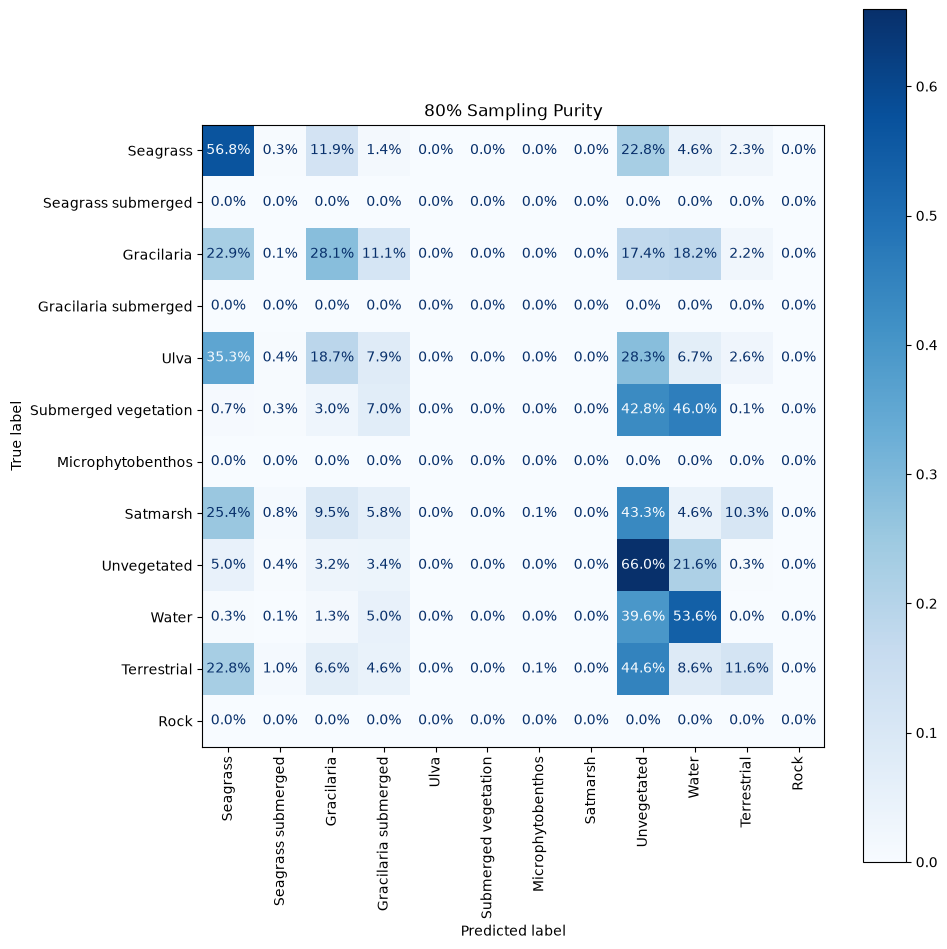

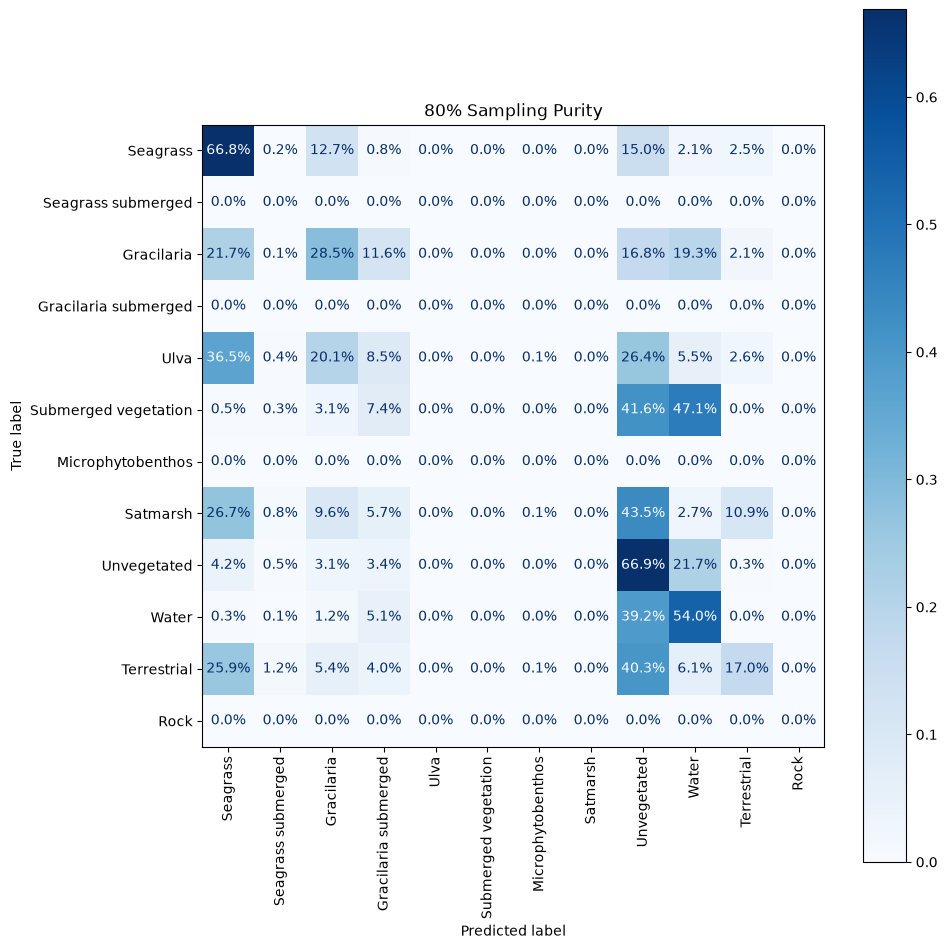

In [28]:
if not test_prediction_file.exists():
    predictions, satellite_data = training.predict_site_unet(test_satellite_file=test_satellite_file, polygon_file=test_polygon_file,
                                                             checkpoint_file=best_model_path)
    utils.save_netcdf(predictions, test_prediction_file)
else:
    print(f"Prediction file '{test_prediction_file.name}' already eixsts. Delete if you want to repredict.")
    satellite_data = utils.load_satellite(filename=test_satellite_file)
    predictions = utils.load_classification(filename=test_prediction_file, chunks=None)

'''print(
    f"Satellite training classes present: {[key for key, value in satellite_classes.items() if value in training_dataframe['satellite_class_id'].unique()]}. "
    f"Predicted classes present: {[key for key, value in satellite_classes.items() if value in numpy.unique(predictions.data)]}"
     )'''

training.confusion_matrix_of_site(
    test_uav_file=test_uav_file,
    uav_labels_file=uav_labels_file,
    prediction_file=test_prediction_file,
    satellite_classes=satellite_classes,
    satellite_from_uav_classes=satellite_classes_from_uav_classes,
    uav_classes_to_ignore=uav_classes_to_ignore,
    polygon_file=test_polygon_file,
    method_2_threshold=method_2_threshold,
    match_satellite_resolution=False,
);

training.confusion_matrix_of_site(
    test_uav_file=test_uav_file,
    uav_labels_file=uav_labels_file,
    prediction_file=test_prediction_file,
    satellite_classes=satellite_classes,
    satellite_from_uav_classes=satellite_classes_from_uav_classes,
    uav_classes_to_ignore=uav_classes_to_ignore,
    polygon_file=test_polygon_file,
    method_2_threshold=method_2_threshold,
    match_satellite_resolution=True,
);
